In [27]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

from helpers import *

device: cuda


In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
H, W = 120, 40
weights_path = Path("fusion_epochs/fusion_epoch_2193.pth")
assert weights_path.exists(), f"Missing checkpoint: {weights_path}"

num_train_steps = 1000
schedule = build_schedule(num_train_steps=num_train_steps, device=device)

model = MyTinyUNet(in_c=1, out_c=1, n_steps=num_train_steps).to(device)
raw_state = torch.load(weights_path, map_location=device)

if isinstance(raw_state, dict) and "state_dict" in raw_state:
    raw_state = raw_state["state_dict"]

if isinstance(raw_state, dict) and any(k.startswith("network.") for k in raw_state.keys()):
    net_state = {k[len("network."):]: v for k, v in raw_state.items() if k.startswith("network.")}
else:
    net_state = raw_state

missing, unexpected = model.load_state_dict(net_state, strict=False)
print("missing keys:", len(missing))
print("unexpected keys:", len(unexpected))
if missing or unexpected:
    raise RuntimeError("Checkpoint/model mismatch. Check architecture or key prefix handling.")

missing keys: 0
unexpected keys: 0


In [30]:
from scipy import ndimage

def preprocess_magnetic_data(data_exp, Nz, Nr, doublet=False):
    # interpolate original equilibria on the prescribed inversion grid
    eqs = np.zeros((data_exp["psi"].shape[2], Nz, Nr))
    rs = data_exp['liuqe_rs'][:, 0]
    zs = data_exp['liuqe_zs'][:, 0]
    dr_liuqe = np.mean(np.diff(rs.flatten()))
    dz_liuqe = np.mean(np.diff(zs.flatten()))
    tcv_zmin, tcv_zmax = -0.75, 0.75
    tcv_rmin, tcv_rmax = 0.624, 1.1376
    dz, dr = (tcv_zmax - tcv_zmin) / Nz, (tcv_rmax - tcv_rmin) / Nr
    tcv_Zs = np.linspace(tcv_zmin, tcv_zmax, Nz + 1, endpoint=True)[:-1] + dz / 2
    tcv_Rs = np.linspace(tcv_rmin, tcv_rmax, Nr + 1, endpoint=True)[:-1] + dr / 2
    for i in range(data_exp['psi'].shape[2]):
        # convert inversion grid coordinates to image coordinates
        r_pos_evals = (tcv_Rs - rs.min()) / dr_liuqe
        z_pos_evals = -(np.flip(tcv_Zs) - zs.max()) / dz_liuqe
        coord_eval_pos = np.zeros((2, Nz * Nr))
        for nz in range(Nz):
            for nr in range(Nr):
                coord_eval_pos[0, nr + nz * Nr] = z_pos_evals[nz]
                coord_eval_pos[1, nr + nz * Nr] = r_pos_evals[nr]
        if doublet:
            # for doublet, flip the original equilibrium to match the new grid orientation
             eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i], axis=0),
                                                            coord_eval_pos, order=2, mode="nearest",
                                                            prefilter=True).reshape(Nz, Nr)
        else:
            # evaluate original fbte input on the prescribed inversion grid
            eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i].T, axis=0),
                                                                coord_eval_pos, order=2, mode="nearest",
                                                                prefilter=True).reshape(Nz, Nr)
    return eqs

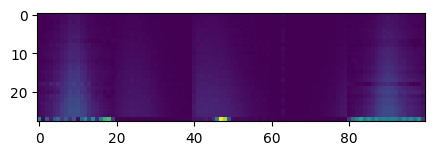

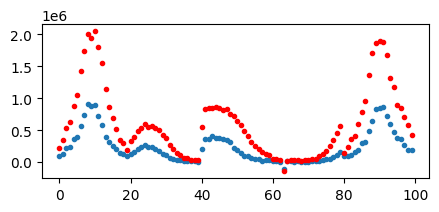

In [31]:
import scipy.io as scio
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

doublet = True

exp_data = scio.loadmat('experimental_data/shot_data_85270.mat')['data'][0, 0] # singlet
psi=preprocess_magnetic_data(exp_data, Nz=120, Nr=40, doublet=False)
if doublet:
    exp_data = scio.loadmat('experimental_data/shot_data_87262.mat')['data'][0, 0] # doublet
    psi=preprocess_magnetic_data(exp_data, Nz=120, Nr=40, doublet=True)

exp_data.dtype

plt.figure(figsize=(5, 2))
plt.imshow(np.abs(exp_data["measurements"]))
#plt.yticks([0,10,20], labels=[str(exp_data["measurements_times"].flatten()[0]), str(exp_data["measurements_times"].flatten()[10]), str(exp_data["measurements_times"].flatten()[20])])
plt.show()
plt.figure(figsize=(5, 2))
plt.plot(exp_data["measurements"][10,:], '.')
plt.plot(exp_data["measurements"][26,:], 'r.')

### diffusion

A_tomo: (99, 4800)


Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

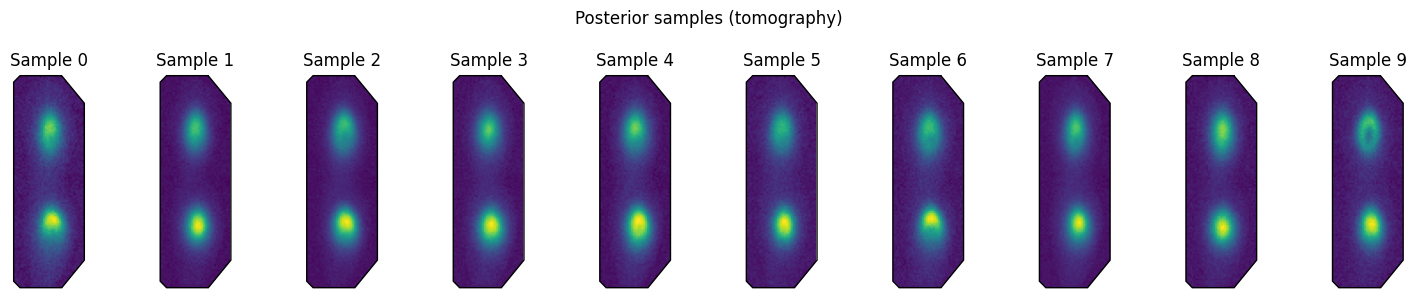

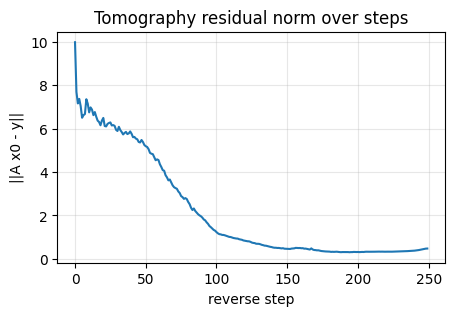

In [32]:
A_path = Path("forward_model/forward_model_sxr_full_geometry.npy") # sparse_mat_artificial_coarse_random_1e4.npz or sparse_geometry_matrix_sxr.npz or forward_model_sxr_full_geometry.npy
assert A_path.exists(), f"Missing forward matrix: {A_path}"

good_channels = exp_data['good_channels'].flatten() - 1
#good_channels = np.setdiff1d(good_channels, np.array([20,21,22,23]))

A_sparse = np.load(A_path).astype(np.float32) * 1e9 # rescale if forward_model_sxr_full_geometry
A_sparse = A_sparse[good_channels, :] # remove faulty channels
A_tomo = torch.from_numpy(A_sparse).to(device)
print("A_tomo:", tuple(A_tomo.shape))

exp_idx = 10
if doublet :
    exp_idx= 26 # 5, 10, 26
    
y_tomo = np.array(exp_data["measurements"][exp_idx, :] * exp_data["etendues"].flatten() * 4 * np.pi) 
y_tomo = y_tomo[good_channels] # remove faulty channels
y_tomo = torch.from_numpy(y_tomo).to(device=device, dtype=torch.float32)
y_tomo /= torch.max(y_tomo)


sigma_y_tomo = 0.01

posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_tomo,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=0.6,
    sigma_y=sigma_y_tomo,
    lambda_=2000,  
    clip_range=None,
)

# sigma_real_data = 0.01
# posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_dps(
#     model=model,
#     schedule=schedule,
#     A=A_tomo,
#     y=y_tomo,
#     image_shape=(1, H, W),
#     num_samples=100,
#     num_inference_steps=250,
#     eta=0., # 0 for sparse_mat_artificial_coarse_random_1e4
#     sigma_y=sigma_real_data,
#     guidance_scale=0.6,  # 0.3 for sparse_mat_artificial_coarse_random_1e4 model
#     clip_range=None,
# )

show_samples(posterior_tomo[:10], title="Posterior samples (tomography)", ncols=10)

plt.figure(figsize=(5, 3))
plt.plot(tomo_residuals)
plt.title("Tomography residual norm over steps")
plt.xlabel("reverse step")
plt.ylabel("||A x0 - y||")
plt.grid(True, alpha=0.3)
plt.show()


In [33]:
print("A (min, max):", A_tomo.min().item(), A_tomo.max().item())
print("y (min, max):", y_tomo.min().item(), y_tomo.max().item())
print("sigma_y_tomo:", sigma_y_tomo)

A (min, max): 0.0 0.1435626894235611
y (min, max): 0.030281733721494675 1.0
sigma_y_tomo: 0.01


### reaction-diffusion

In [34]:
import scipy.sparse as sp
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
from pyxu_diffops.operator import AnisDiffusionOp

sigma_err = 0.05
anis_param = 1e-3
reg_param = 1e-1
with_positivity_constraint = True

noisy_tomo_data = y_tomo.cpu().numpy().reshape(1, -1)

f = fct_def._DataFidelityFunctional(
    dim_shape=(1, H, W),
    noisy_tomo_data=noisy_tomo_data,
    sigma_err=sigma_err,
    geometry_matrix=sp.csr_matrix(A_tomo.cpu().numpy()),
)
g = AnisDiffusionOp(
    dim_shape=(1, H, W),
    alpha=anis_param,
    diff_method_struct_tens="fd",
    freezing_arr=psi[exp_idx],
    sampling=0.0125,
    matrix_based_impl=True,
)

im_map = bcomp.compute_MAP(
    f, g, reg_param,
    with_pos_constraint=with_positivity_constraint,
    clipping_mask=None,
    show_progress=True,
)

x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)

INFO -- [2026-04-16 19:02:48.177966] Iteration 0
	iteration: 0
	N_iter: 1
	RelError[x]: 0
INFO -- [2026-04-16 19:02:48.681665] Iteration 1_000
	iteration: 1000
	N_iter: 1001
	RelError[x]: 0
INFO -- [2026-04-16 19:02:49.183897] Iteration 2_000
	iteration: 2000
	N_iter: 2001
	RelError[x]: 0
INFO -- [2026-04-16 19:02:49.366783] Iteration 2_363
	iteration: 2363
	N_iter: 2364
	RelError[x]: 0
INFO -- [2026-04-16 19:02:49.367647] Stopping Criterion satisfied -> END


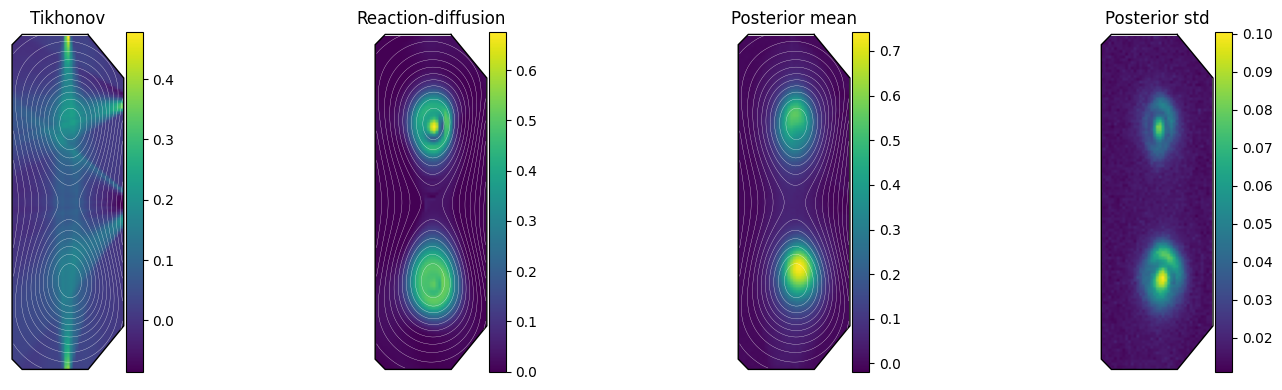

In [35]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------

post_mean = posterior_tomo.mean(dim=0, keepdim=True)
post_std  = posterior_tomo.std(dim=0, keepdim=True)

# Tikhonov baseline (pure physics inversion, no diffusion prior)
lambda_tikh = 1e-1
AtA    = A_tomo.T @ A_tomo
Aty    = A_tomo.T @ y_tomo
x_tikh = torch.linalg.solve(AtA + lambda_tikh * torch.eye(AtA.shape[0], device=device), Aty)
x_tikh = x_tikh.view(1, 1, H, W)

psi_slice = psi[exp_idx]

summary = torch.stack([
    x_tikh[0, 0].cpu(),
    x_map[0, 0].cpu(),
    post_mean[0, 0].cpu(),
    post_std[0, 0].cpu(),
])
show_samples(
    summary,
    titles=["Tikhonov", "Reaction-diffusion", "Posterior mean", "Posterior std"],
    ncols=4,
    figsize=(16, 4),
    contour_images=[psi_slice, psi_slice, psi_slice, None],
    colorbar=True,
)